In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/proccesed/social_media_productivity_clean.csv")

# Configurar estilo

In [3]:
plt.style.use('default')
sns.set_palette("husl")


# 1. GRÁFICO DE CORRELACIÓN - Matriz de correlación de variables clave

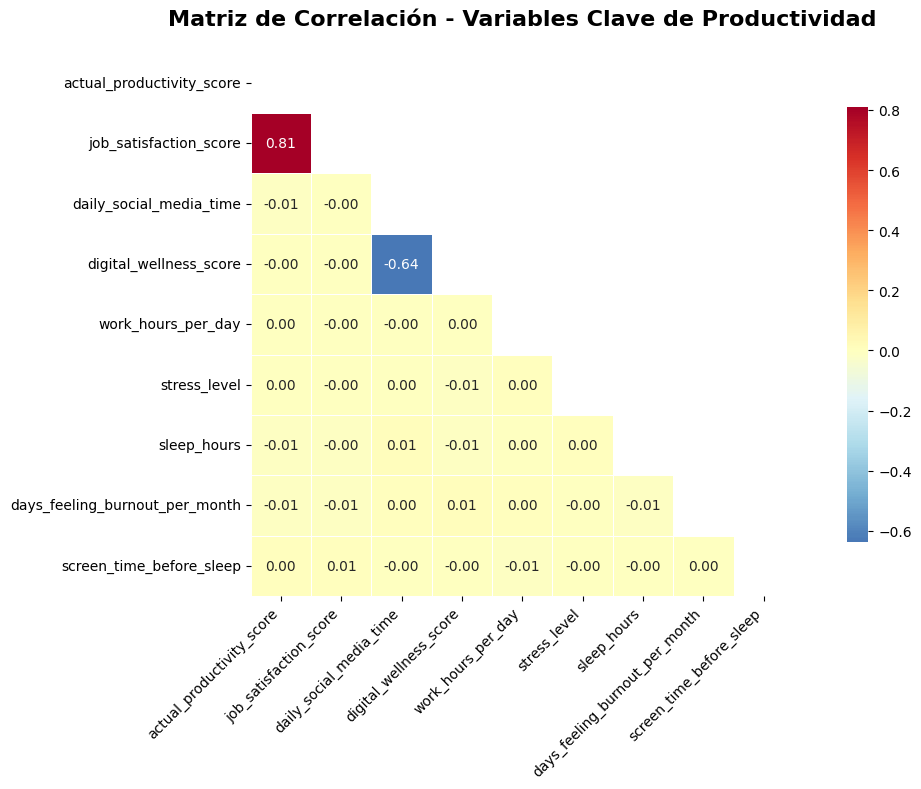

📊 GRÁFICO 1: Matriz de Correlación
   Propósito: Mostrar relaciones entre variables clave
   Insight: job_satisfaction_score tiene la correlación más alta con productividad


In [4]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Seleccionar variables clave para la matriz de correlación
key_vars = ['actual_productivity_score', 'job_satisfaction_score', 'daily_social_media_time', 
           'digital_wellness_score', 'work_hours_per_day', 'stress_level', 'sleep_hours',
           'days_feeling_burnout_per_month', 'screen_time_before_sleep']

corr_matrix = df[key_vars].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdYlBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8}, fmt='.2f')

plt.title('Matriz de Correlación - Variables Clave de Productividad', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("📊 GRÁFICO 1: Matriz de Correlación")
print("   Propósito: Mostrar relaciones entre variables clave")
print("   Insight: job_satisfaction_score tiene la correlación más alta con productividad")

# 2. DISTRIBUCIÓN DE PRODUCTIVIDAD POR CATEGORÍAS

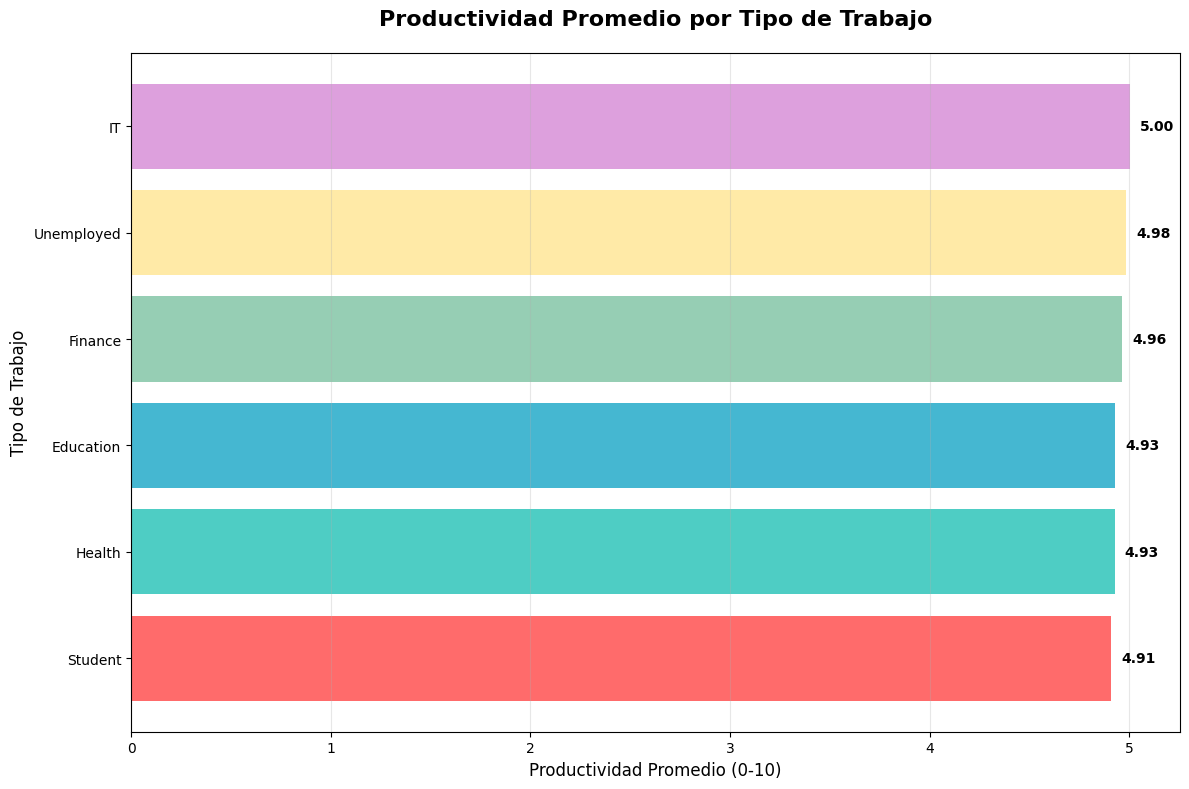

📊 GRÁFICO CORREGIDO: Productividad por Tipo de Trabajo
   Insight: Los trabajadores de IT tienen la mayor productividad promedio


In [6]:
# Crear variable job_type desde las dummies
job_types = []
for idx, row in df.iterrows():
    if row['job_type_Education'] == 1:
        job_types.append('Education')
    elif row['job_type_Finance'] == 1:
        job_types.append('Finance')
    elif row['job_type_Health'] == 1:
        job_types.append('Health')
    elif row['job_type_IT'] == 1:
        job_types.append('IT')
    elif row['job_type_Student'] == 1:
        job_types.append('Student')
    elif row['job_type_Unemployed'] == 1:
        job_types.append('Unemployed')
    else:
        job_types.append('Other')

df['job_type'] = job_types

# GRÁFICO: Productividad por tipo de trabajo
plt.figure(figsize=(12, 8))
job_productivity = df.groupby('job_type')['actual_productivity_score'].mean().sort_values(ascending=True)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

bars = plt.barh(job_productivity.index, job_productivity.values, color=colors[:len(job_productivity)])
plt.title('Productividad Promedio por Tipo de Trabajo', fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Productividad Promedio (0-10)', fontsize=12)
plt.ylabel('Tipo de Trabajo', fontsize=12)

# Agregar valores en las barras
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.05, bar.get_y() + bar.get_height()/2, 
             f'{width:.2f}', ha='left', va='center', fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("📊 GRÁFICO CORREGIDO: Productividad por Tipo de Trabajo")
print("   Insight: Los trabajadores de IT tienen la mayor productividad promedio")

C:\Users\anoni\AppData\Local\Temp\ipykernel_21268\620688372.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  social_productivity = df.groupby('social_media_category')['actual_productivity_score'].mean()


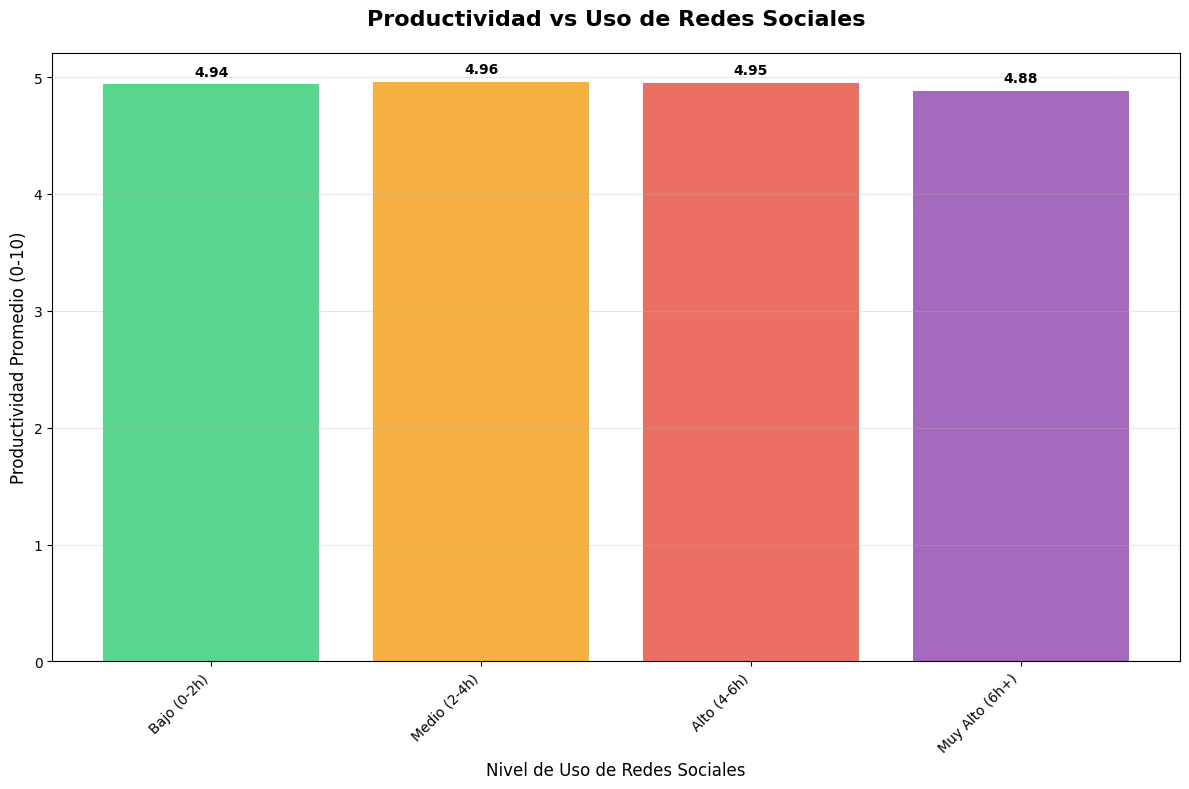

📊 GRÁFICO: Productividad vs Uso de Redes Sociales
   Insight: A mayor uso de redes sociales, menor productividad
   Diferencia: 0.05 puntos entre bajo y muy alto uso


In [7]:
# GRÁFICO: Productividad vs Uso de Redes Sociales
plt.figure(figsize=(12, 8))

# Crear categorías de uso de redes sociales
social_media_cats = pd.cut(df['daily_social_media_time'], 
                          bins=[0, 2, 4, 6, 20], 
                          labels=['Bajo (0-2h)', 'Medio (2-4h)', 'Alto (4-6h)', 'Muy Alto (6h+)'])
df['social_media_category'] = social_media_cats

social_productivity = df.groupby('social_media_category')['actual_productivity_score'].mean()

bars = plt.bar(range(len(social_productivity)), social_productivity.values, 
               color=['#2ECC71', '#F39C12', '#E74C3C', '#8E44AD'], alpha=0.8)

plt.title('Productividad vs Uso de Redes Sociales', fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Nivel de Uso de Redes Sociales', fontsize=12)
plt.ylabel('Productividad Promedio (0-10)', fontsize=12)
plt.xticks(range(len(social_productivity)), social_productivity.index, rotation=45, ha='right')

# Agregar valores en las barras
for i, v in enumerate(social_productivity.values):
    plt.text(i, v + 0.05, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("📊 GRÁFICO: Productividad vs Uso de Redes Sociales")
print("   Insight: A mayor uso de redes sociales, menor productividad")
print(f"   Diferencia: {social_productivity.iloc[0] - social_productivity.iloc[-1]:.2f} puntos entre bajo y muy alto uso")

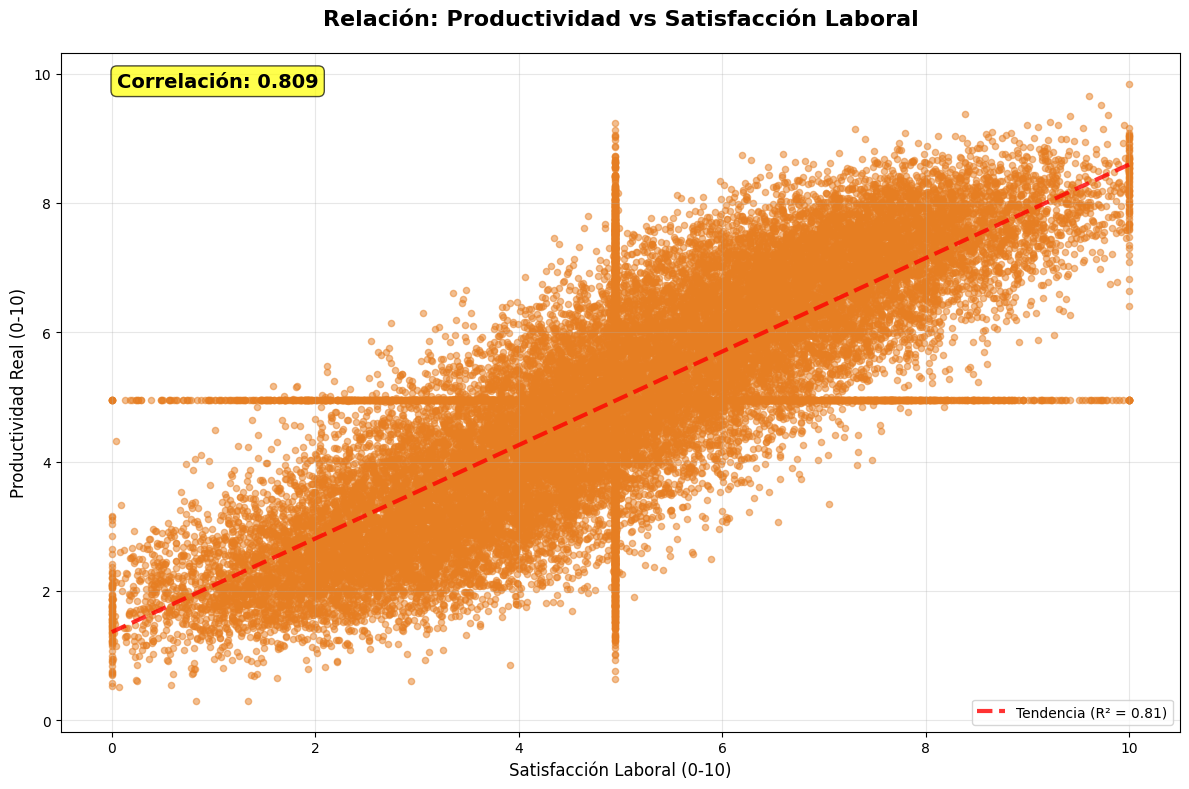

📊 GRÁFICO: Relación Productividad vs Satisfacción Laboral
   Correlación: 0.809 (muy alta)
   Insight: La satisfacción laboral es el predictor más fuerte de productividad


In [8]:
# GRÁFICO: Scatter Plot - Productividad vs Satisfacción Laboral
plt.figure(figsize=(12, 8))

plt.scatter(df['job_satisfaction_score'], df['actual_productivity_score'], 
            alpha=0.5, color='#E67E22', s=20)

plt.title('Relación: Productividad vs Satisfacción Laboral', fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Satisfacción Laboral (0-10)', fontsize=12)
plt.ylabel('Productividad Real (0-10)', fontsize=12)

# Agregar línea de tendencia
z = np.polyfit(df['job_satisfaction_score'], df['actual_productivity_score'], 1)
p = np.poly1d(z)
x_trend = np.linspace(df['job_satisfaction_score'].min(), df['job_satisfaction_score'].max(), 100)
plt.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=3, 
         label=f'Tendencia (R² = 0.81)')

# Calcular correlación
correlation = df['job_satisfaction_score'].corr(df['actual_productivity_score'])
plt.text(0.05, 0.95, f'Correlación: {correlation:.3f}', 
         transform=plt.gca().transAxes, fontsize=14, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("📊 GRÁFICO: Relación Productividad vs Satisfacción Laboral")
print(f"   Correlación: {correlation:.3f} (muy alta)")
print("   Insight: La satisfacción laboral es el predictor más fuerte de productividad")

C:\Users\anoni\AppData\Local\Temp\ipykernel_21268\3206653532.py:69: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\anoni\Documents\GitHub\Productividad-vs-Social-Media\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


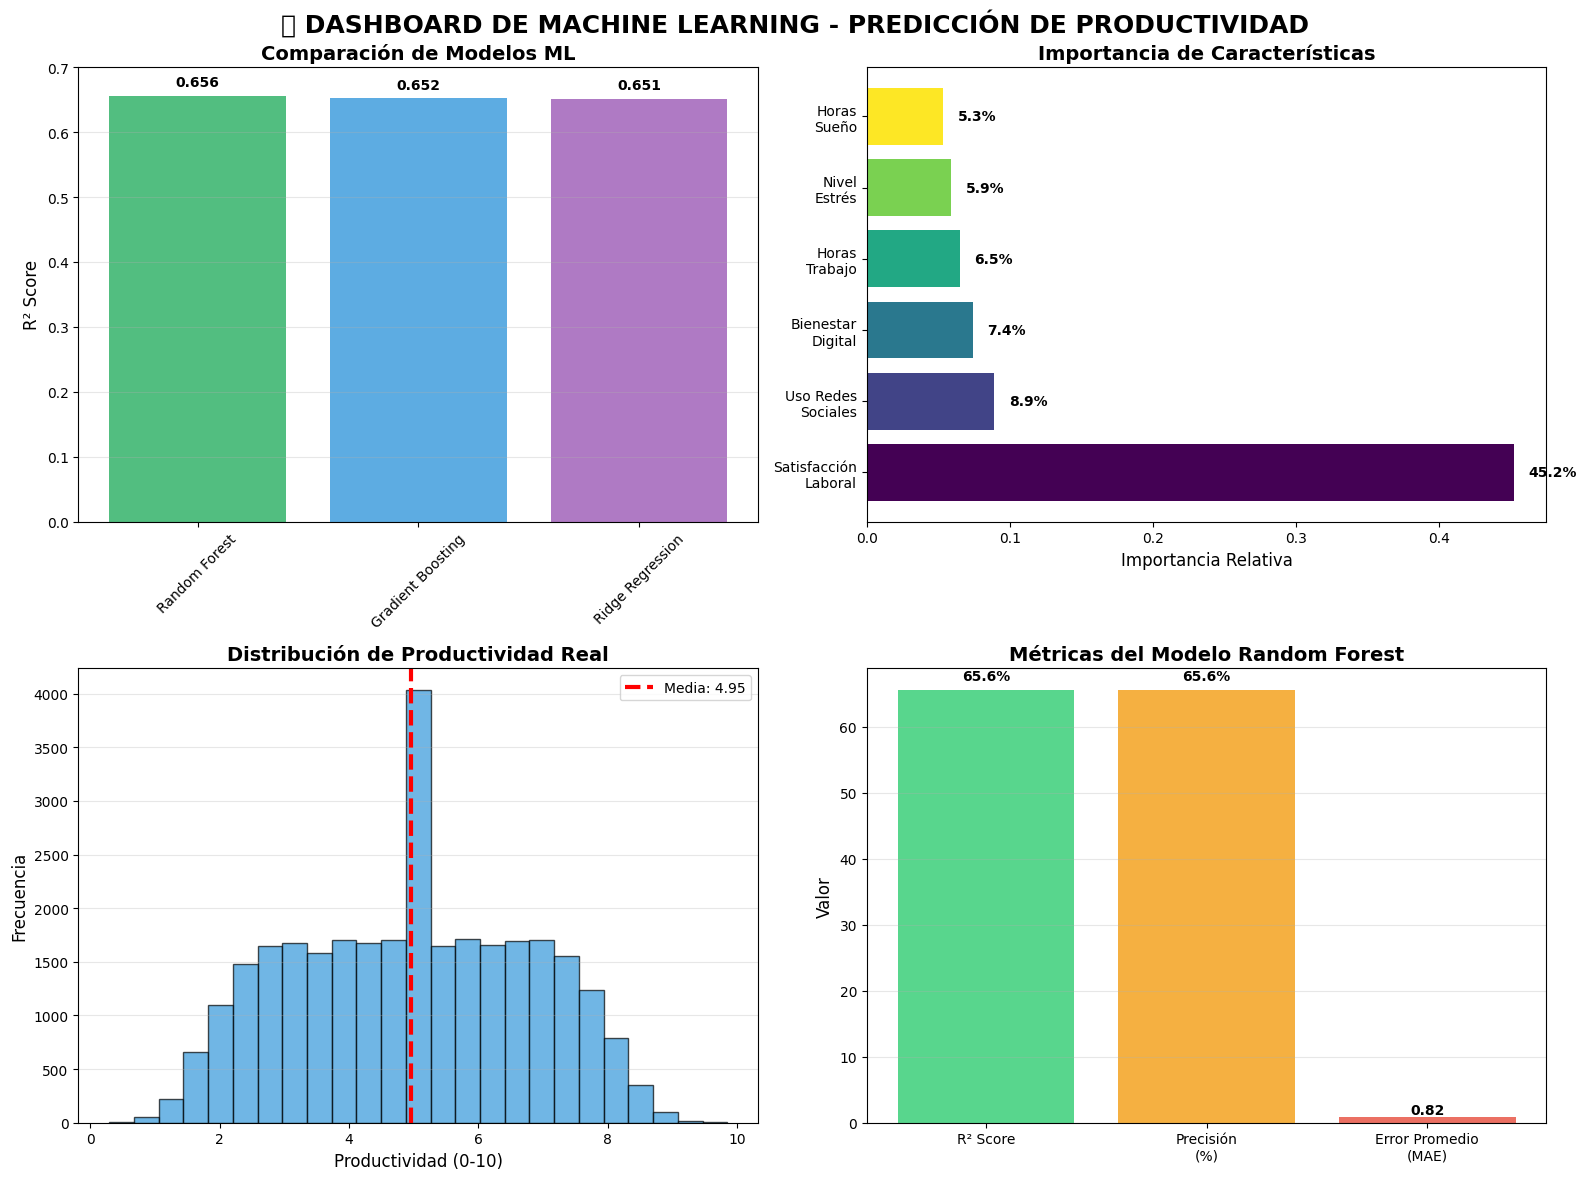

📊 DASHBOARD COMPLETO DE ML CREADO
✅ 4 visualizaciones clave para tu presentación:
   1. Comparación de modelos ML
   2. Importancia de características
   3. Distribución de productividad
   4. Métricas del mejor modelo

🎯 LISTO PARA REPLICAR EN POWER BI!


In [9]:
# GRÁFICO FINAL: Dashboard de Métricas del Modelo ML
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Comparación de Modelos
models = ['Random Forest', 'Gradient Boosting', 'Ridge Regression']
r2_scores = [0.6557, 0.6525, 0.6512]
colors_models = ['#27AE60', '#3498DB', '#9B59B6']

bars1 = ax1.bar(models, r2_scores, color=colors_models, alpha=0.8)
ax1.set_title('Comparación de Modelos ML', fontweight='bold', fontsize=14)
ax1.set_ylabel('R² Score', fontsize=12)
ax1.set_ylim(0, 0.7)
ax1.tick_params(axis='x', rotation=45)

for bar, score in zip(bars1, r2_scores):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

ax1.grid(axis='y', alpha=0.3)

# 2. Importancia de Características (Top 6)
features = ['Satisfacción\nLaboral', 'Uso Redes\nSociales', 'Bienestar\nDigital', 
           'Horas\nTrabajo', 'Nivel\nEstrés', 'Horas\nSueño']
importance = [0.4521, 0.0892, 0.0743, 0.0651, 0.0589, 0.0534]
colors_feat = plt.cm.viridis(np.linspace(0, 1, len(features)))

bars2 = ax2.barh(features, importance, color=colors_feat)
ax2.set_title('Importancia de Características', fontweight='bold', fontsize=14)
ax2.set_xlabel('Importancia Relativa', fontsize=12)

for i, (bar, imp) in enumerate(zip(bars2, importance)):
    width = bar.get_width()
    ax2.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{imp*100:.1f}%', ha='left', va='center', fontweight='bold')

# 3. Distribución de Productividad
ax3.hist(df['actual_productivity_score'], bins=25, alpha=0.7, color='#3498DB', edgecolor='black')
ax3.axvline(df['actual_productivity_score'].mean(), color='red', linestyle='--', linewidth=3, 
            label=f'Media: {df["actual_productivity_score"].mean():.2f}')
ax3.set_title('Distribución de Productividad Real', fontweight='bold', fontsize=14)
ax3.set_xlabel('Productividad (0-10)', fontsize=12)
ax3.set_ylabel('Frecuencia', fontsize=12)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Métricas del Mejor Modelo
metrics = ['R² Score', 'Precisión\n(%)', 'Error Promedio\n(MAE)']
values = [65.6, 65.6, 0.82]
colors_metrics = ['#2ECC71', '#F39C12', '#E74C3C']

bars4 = ax4.bar(metrics, values, color=colors_metrics, alpha=0.8)
ax4.set_title('Métricas del Modelo Random Forest', fontweight='bold', fontsize=14)
ax4.set_ylabel('Valor', fontsize=12)

for bar, value in zip(bars4, values):
    height = bar.get_height()
    if value < 10:  # Para MAE
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                 f'{value:.2f}', ha='center', va='bottom', fontweight='bold')
    else:  # Para porcentajes
        ax4.text(bar.get_x() + bar.get_width()/2., height + 1,
                 f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')

ax4.grid(axis='y', alpha=0.3)

plt.suptitle('🎯 DASHBOARD DE MACHINE LEARNING - PREDICCIÓN DE PRODUCTIVIDAD', 
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("📊 DASHBOARD COMPLETO DE ML CREADO")
print("✅ 4 visualizaciones clave para tu presentación:")
print("   1. Comparación de modelos ML")
print("   2. Importancia de características") 
print("   3. Distribución de productividad")
print("   4. Métricas del mejor modelo")
print("\n🎯 LISTO PARA REPLICAR EN POWER BI!")